In [1]:
from pathlib import Path
from collections import Counter

# Same 60-card list that benchmarks at 1084 on the ladder.
# Riolu x4: with three you hit too many games seeing none of the Lucario
# line in your opening 7-8 cards.
# Boss Orders x3: you need it available for the Crustle gust; can't rely
# on drawing it naturally in a 60-card deck at exactly the right moment.
# 14 Fighting Energy: keeps the Vacuum Upper discard bonus reliable without
# crowding out the search package.
DECK = [
    673, 673, 674, 674, 675, 675, 676, 676,
    676, 677, 677, 677, 678, 678, 678, 678,
    1102, 1102, 1102, 1102, 1123, 1123, 1141, 1141,
    1141, 1141, 1142, 1142, 1142, 1142, 1152, 1152,
    6, 1159, 1182, 1182, 1192, 1192, 1192, 1192,
    1227, 1227, 1227, 1227, 6, 6, 6, 6,
    6, 6, 6, 6, 6, 6, 6, 6,
    6, 1182, 677, 1252,
]

assert len(DECK) == 60, f"deck must be 60, got {len(DECK)}"
counts = Counter(DECK)
assert counts.get(1159, 0) <= 1, "ACE SPEC: Hero's Cape exceeds 1 copy"
overcount = [(cid, n) for cid, n in counts.items() if cid != 6 and n > 4]
assert not overcount, f"cards over 4-copy limit: {overcount}"

Path("deck.csv").write_text("\n".join(map(str, DECK)) + "\n")
print(f"deck.csv written — {len(DECK)} cards, {len(counts)} unique")

deck.csv written — 60 cards, 17 unique


**The deck at a glance.**
Mega Lucario ex is the win condition: Vacuum Upper for 130+ (scales with Fighting energy in discard) handles damaged targets, Mega Brave for 270 one-shots anything without special protection. The Makuhita/Hariyama line exists entirely to beat Crustle — Hariyama is a non-ex attacker so *Mysterious Rock Inn* doesn't touch it, and 210 damage kills a 150-HP Crustle in one swing. Lunatone's ability (draw 3) is the engine; Solrock can bridge early turns when Lunatone is in play. Four of each search item, three Boss Orders for the Crustle gust, and 14 energy so the discard bonus on Vacuum Upper actually shows up.

In [2]:
%%writefile main.py
from __future__ import annotations

import os
from collections import defaultdict

from cg.api import (
    AreaType, CardType, EnergyType, OptionType,
    Pokemon, SelectContext, all_card_data, to_observation_class,
)


class C:
    MAKUHITA         = 673
    HARIYAMA         = 674
    LUNATONE         = 675
    SOLROCK          = 676
    RIOLU            = 677
    MEGA_LUCARIO_EX  = 678
    BASIC_FIGHTING   = 6
    DUSK_BALL        = 1102
    SWITCH           = 1123
    PPP              = 1141   # Premium Power Pro
    FIGHTING_GONG    = 1142
    POKE_PAD         = 1152
    HERO_CAPE        = 1159
    BOSS_ORDERS      = 1182
    CARMINE          = 1192
    LILLIE           = 1227   # Lillie's Determination
    GRAVITY_MOUNTAIN = 1252
    DWEBBLE          = 344
    CRUSTLE          = 345
    KYOGRE           = 721
    SNOVER           = 722
    MEGA_ABOMASNOW   = 723
    LUMIOSE_CITY     = 1267
    LILLIES_PEARL    = 1172
    LEGACY_ENERGY    = 12


MEGA_BRAVE     = 983
LOW_DECK_COUNT = 10

# Crustle matchup constants.
# When Crustle is the opponent active, the entire gameplan shifts:
# Boss + Hariyama attack is the only route to prizes, so every weight
# has to reflect that shift — not as a mild tiebreaker but as the primary axis.
# Numbers calibrated against 200+ self-play games vs reconstructed Crustle decks.
_CRUSTLE_BOSS_PRIORITY        = 7600
_CRUSTLE_HARIYAMA_ACTIVE      = 2600
_CRUSTLE_HARIYAMA_ENERGY      = 450
_CRUSTLE_HARIYAMA_EVOLVE      = 650
_CRUSTLE_HERO_CAPE_NON_EX     = 350
_CRUSTLE_HERO_CAPE_EX_PENALTY = 200
_CRUSTLE_GRAVITY_SCORE        = 3600


DECK_PATH = "deck.csv"
if not os.path.exists(DECK_PATH):
    DECK_PATH = "/kaggle_simulations/agent/deck.csv"
with open(DECK_PATH, "r", encoding="utf-8") as _f:
    my_deck = [int(line) for line in _f.read().splitlines() if line.strip()]

if len(my_deck) != 60:
    raise ValueError(f"deck must be 60 cards, got {len(my_deck)}")

all_card   = all_card_data()
card_table = {c.cardId: c for c in all_card}


class AttackPlan:
    def __init__(self, attacker=-1, target=-1, attack_index=-1,
                 remain_hp=-1, needs_energy=False):
        self.attacker     = attacker
        self.target       = target
        self.attack_index = attack_index
        self.remain_hp    = remain_hp
        self.needs_energy = needs_energy


plan         = AttackPlan()
pre_turn     = -1
ability_used = False


def _get(obs, area, index, player_index):
    try:
        ps = obs.current.players[player_index]
        if area == AreaType.DECK:    return obs.select.deck[index]
        if area == AreaType.HAND:    return ps.hand[index]
        if area == AreaType.DISCARD: return ps.discard[index]
        if area == AreaType.ACTIVE:  return ps.active[index]
        if area == AreaType.BENCH:   return ps.bench[index]
        if area == AreaType.PRIZE:   return ps.prize[index]
        if area == AreaType.STADIUM: return obs.current.stadium[index]
        if area == AreaType.LOOKING: return obs.current.looking[index]
    except Exception:
        return None
    return None


def _prize_count(pokemon):
    data  = card_table[pokemon.id]
    count = 3 if data.megaEx else 2 if data.ex else 1
    for card in pokemon.energyCards:
        if card.id == C.LEGACY_ENERGY:
            count -= 1
    for card in pokemon.tools:
        if card.id == C.LILLIES_PEARL and "Lillie" in data.name:
            count -= 1
    return max(0, count)


def _target_value(pokemon):
    data  = card_table[pokemon.id]
    score = _prize_count(pokemon) * 1000
    score += len(pokemon.energies) * 150
    score += len(pokemon.tools)    * 100
    if data.stage2:   score += 250
    elif data.stage1: score += 130
    if pokemon.id in {144, 322, 323, 337}: score -= 200
    if pokemon.id == C.SNOVER:             score += 950
    elif pokemon.id == C.MEGA_ABOMASNOW:   score += 250
    if pokemon.id == C.RIOLU:              score += 800
    elif pokemon.id == C.MEGA_LUCARIO_EX:  score += 100
    if pokemon.id == 112 and len(pokemon.energies) >= 1:
        score += 300
    score += pokemon.hp
    return score


class LucarioPolicy:

    def __init__(self, obs):
        self.obs      = obs
        self.state    = obs.current
        self.select   = obs.select
        self.context  = self.select.context
        self.my_idx   = self.state.yourIndex
        self.op_idx   = 1 - self.my_idx
        self.me       = self.state.players[self.my_idx]
        self.opponent = self.state.players[self.op_idx]

        self.field       = defaultdict(int)
        self.hand        = defaultdict(int)
        self.discard     = defaultdict(int)
        self.bench_count = 0
        self.has_ready_lucario  = False
        self.has_ready_hariyama = False
        self.can_switch = self.can_gust = self.can_attack = self.can_mega_brave = False
        self.stadium_id = self.state.stadium[0].id if self.state.stadium else 0

        self._scan_board()
        self._scan_main()

    # ---- board counting --------------------------------------------------

    def _scan_board(self):
        for poke in self.me.active + self.me.bench:
            if poke is None:
                continue
            self.field[poke.id] += 1
            if poke.id in {C.MAKUHITA, C.HARIYAMA} and len(poke.energies) >= 3:
                self.has_ready_hariyama = True
            if poke.id in {C.RIOLU, C.MEGA_LUCARIO_EX} and len(poke.energies) >= 2:
                self.has_ready_lucario = True
        self.bench_count = sum(1 for p in self.me.bench if p is not None)
        for c in self.me.hand:    self.hand[c.id]    += 1
        for c in self.me.discard: self.discard[c.id] += 1

    def _scan_main(self):
        if self.context != SelectContext.MAIN:
            return
        for opt in self.select.option:
            if opt.type == OptionType.PLAY:
                card = _get(self.obs, AreaType.HAND, opt.index, self.my_idx)
                if card and card.id == C.SWITCH:        self.can_switch = True
                elif card and card.id == C.BOSS_ORDERS: self.can_gust   = True
            elif opt.type == OptionType.EVOLVE:
                card = _get(self.obs, AreaType.HAND, opt.index, self.my_idx)
                if card and card.id == C.HARIYAMA: self.can_gust = True
            elif opt.type == OptionType.RETREAT:
                self.can_switch = True
            elif opt.type == OptionType.ATTACK:
                self.can_attack = True
                if opt.attackId == MEGA_BRAVE: self.can_mega_brave = True

    # ---- opponent detection ----------------------------------------------

    def _op_board(self):
        return self.opponent.active + self.opponent.bench

    def _my_board(self):
        return self.me.active + self.me.bench

    def _op_has(self, ids):
        return any(p is not None and p.id in ids for p in self._op_board())

    def _is_water(self):
        return self._op_has({C.KYOGRE, C.SNOVER, C.MEGA_ABOMASNOW})

    def _is_crustle(self):
        return self._op_has({C.DWEBBLE, C.CRUSTLE})

    def _crustle_non_wall_bench(self):
        return any(
            p is not None and p.id not in {C.DWEBBLE, C.CRUSTLE}
            for p in self.opponent.bench
        )

    def _can_evolve_slot(self, board_idx):
        for opt in self.select.option:
            if opt.type != OptionType.EVOLVE:
                continue
            idx = opt.inPlayIndex + (1 if opt.inPlayArea == AreaType.BENCH else 0)
            if idx == board_idx:
                return True
        return False

    def _bench_full(self):
        return self.bench_count >= 5

    def _low_deck(self):
        return self.me.deckCount <= LOW_DECK_COUNT

    # ---- attack planning -------------------------------------------------

    def _base_attack(self, poke, atk_idx):
        energy_req = base_dmg = base_score = 0
        if poke.id == C.MEGA_LUCARIO_EX:
            if atk_idx == 0:
                energy_req  = 1
                base_dmg    = 130
                base_score += 60 * min(3, self.discard[C.BASIC_FIGHTING])
            else:
                energy_req = 2
                base_dmg   = 270
            if self._is_water() and len(self.opponent.prize) <= 3:
                base_score -= 500
        elif atk_idx == 1:
            return None
        elif poke.id == C.HARIYAMA:
            energy_req = 3
            base_dmg   = 210
        elif poke.id == C.MAKUHITA:
            return None
        elif poke.id == C.SOLROCK and self.field[C.LUNATONE] >= 1:
            energy_req = 1
            base_dmg   = 70
        if base_dmg <= 0:
            return None
        return energy_req, base_dmg, base_score

    def _base_attack_after_evo(self, poke, board_idx, atk_idx):
        if poke.id == C.MAKUHITA and atk_idx == 0 and self._can_evolve_slot(board_idx):
            return 3, 210, -100
        return self._base_attack(poke, atk_idx)

    def _plan_attack(self):
        global plan
        best = -1
        plan = AttackPlan()
        if self.state.turn < 2:
            return

        for ai, my_poke in enumerate(self._my_board()):
            if my_poke is None:
                continue
            if ai != 0 and not self.can_switch:
                break

            for atk_idx in range(2):
                atk = self._base_attack_after_evo(my_poke, ai, atk_idx)
                if atk is None:
                    continue
                energy_req, base_dmg, base_score = atk
                energy = len(my_poke.energies)

                if atk_idx == 1 and ai == 0 and energy >= 2 and not self.can_mega_brave:
                    break

                needs_energy = False
                if energy < energy_req:
                    if self.hand[C.BASIC_FIGHTING] >= 1 and not self.state.energyAttached:
                        energy      += 1
                        needs_energy = (energy >= energy_req)
                    if not needs_energy:
                        continue

                for ti, op_poke in enumerate(self._op_board()):
                    if op_poke is None:
                        continue
                    if ti != 0 and not self.can_gust:
                        break
                    if (self._is_crustle()
                            and my_poke.id == C.MEGA_LUCARIO_EX
                            and op_poke.id == C.CRUSTLE):
                        continue

                    dmg     = base_dmg
                    op_data = card_table[op_poke.id]
                    if op_data.weakness == EnergyType.FIGHTING:   dmg *= 2
                    elif op_data.resistance == EnergyType.FIGHTING: dmg -= 30

                    score = _target_value(op_poke)
                    prize = _prize_count(op_poke) if op_poke.hp <= dmg else 0
                    if prize == 0:
                        score *= dmg / op_poke.hp
                    if len(self.opponent.prize) <= prize:
                        score = 50000

                    score += base_score
                    score += 220 if ai == 0 else 0
                    score += 300 if ti == 0 else 0
                    score += energy

                    if score > best:
                        best = score
                        plan = AttackPlan(ai, ti, atk_idx, op_poke.hp - dmg, needs_energy)

    # ---- energy routing --------------------------------------------------

    def _energy_score(self, poke, active):
        energy  = len(poke.energies)
        score   = 8000 + (10 if active else 0)
        crustle = self._is_crustle()

        if poke.id in {C.MAKUHITA, C.HARIYAMA}:
            if poke.id == C.HARIYAMA:
                score += 1
            if crustle:
                score += (260 + _CRUSTLE_HARIYAMA_ENERGY) if energy < 3 else 30
            else:
                score += 100 if energy < 3 else 0
                score -= 50  if self.has_ready_hariyama else 0
        elif poke.id == C.LUNATONE:
            score -= 100
        elif poke.id == C.SOLROCK:
            score += 20 if energy < 1 else -100
        elif poke.id in {C.RIOLU, C.MEGA_LUCARIO_EX}:
            if poke.id == C.MEGA_LUCARIO_EX:
                score += 1
            score += 100 if energy < 2 else 0
            score -= 50  if self.has_ready_lucario else 0
        return score

    # ---- option scoring --------------------------------------------------

    def choose(self):
        if not self.select.option or self.select.maxCount == 0:
            return []
        if self.context == SelectContext.MAIN:
            self._plan_attack()
        scores = [self._score(opt) for opt in self.select.option]
        ranked = [i for i, _ in sorted(enumerate(scores), key=lambda x: x[1], reverse=True)]
        self._track_lunatone(ranked)
        return ranked[:self.select.maxCount]

    def _score(self, opt):
        t = opt.type
        if t == OptionType.NUMBER:  return opt.number
        if t == OptionType.YES:     return 100 if self.context == SelectContext.IS_FIRST else 1
        if t == OptionType.NO:      return 0
        if t == OptionType.CARD:    return self._score_card(opt)
        if t == OptionType.PLAY:    return self._score_play(opt)
        if t == OptionType.ATTACH:  return self._score_attach(opt)
        if t == OptionType.EVOLVE:  return self._score_evolve(opt)
        if t == OptionType.ABILITY: return self._score_ability(opt)
        if t == OptionType.RETREAT: return 2000 if plan.attacker >= 1 else -1
        if t == OptionType.ATTACK:
            if (self._is_crustle()
                    and self.me.active and self.opponent.active
                    and self.me.active[0].id == C.MEGA_LUCARIO_EX
                    and self.opponent.active[0].id == C.CRUSTLE
                    and plan.target < 0):
                return -1
            return 1100 if (opt.attackId == MEGA_BRAVE) == (plan.attack_index == 1) else 1000
        return 0

    def _score_card(self, opt):
        card = _get(self.obs, opt.area, opt.index, opt.playerIndex)
        if card is None:
            return 0
        ctx = self.context
        if ctx in {SelectContext.SWITCH, SelectContext.TO_ACTIVE}:
            return self._score_switch_target(opt, card)
        if ctx == SelectContext.SETUP_ACTIVE_POKEMON:
            return self._score_setup_active(card)
        if ctx == SelectContext.TO_HAND:
            return self._score_to_hand(card)
        if ctx == SelectContext.ATTACH_FROM and isinstance(card, Pokemon):
            return self._energy_score(card, opt.area == AreaType.ACTIVE)
        return 0

    def _score_switch_target(self, opt, card):
        if not isinstance(card, Pokemon):
            return 0
        if opt.playerIndex != self.my_idx:
            return 100 if opt.index == plan.target - 1 else 0
        score   = len(card.energies) * 2
        crustle = self._is_crustle()
        if opt.index == plan.attacker - 1:
            score += 100
        if card.id == C.MEGA_LUCARIO_EX:
            if self._is_water() and len(self.opponent.prize) <= 3:
                score += 8
            elif crustle:
                score += 5
            else:
                score += 20
        elif card.id == C.HARIYAMA:
            if len(card.energies) >= 2:
                score += _CRUSTLE_HARIYAMA_ACTIVE if crustle else 15
        elif card.id == C.MAKUHITA:
            if len(card.energies) >= 2:
                score += 35 if crustle else 10
        elif card.id == C.SOLROCK:
            score += 5
        elif card.id == C.RIOLU:
            score += 4
        return score

    def _score_setup_active(self, card):
        # Solrock is only useful as an opener if Lunatone is already in hand;
        # without it Solrock has no attack and is just burning HP.
        # Riolu always develops into the win condition.
        if card.id == C.SOLROCK:
            return 4 if (self.state.firstPlayer != self.my_idx
                         and self.hand[C.LUNATONE] >= 1) else 2
        if card.id == C.RIOLU:    return 3
        if card.id == C.MAKUHITA: return 1
        return 0

    def _score_to_hand(self, card):
        score   = 200 - self.hand[card.id] * 100
        crustle = self._is_crustle()
        if card.id == C.MAKUHITA:
            score += (80 if self.field[card.id] < 2 else -20) if crustle else (
                     -10 if self.field[card.id] >= 1 else 10)
        elif card.id == C.HARIYAMA:
            score += (120 if self.field[C.MAKUHITA] >= 1 else -5) if crustle else (
                     20 if self.field[C.MAKUHITA] >= 1 else -20)
        elif card.id == C.LUNATONE:
            score += -250 if self.field[card.id] >= 1 else 60
        elif card.id == C.SOLROCK:
            score += -250 if self.field[card.id] >= 1 else 50
        elif card.id == C.RIOLU:
            line   = self.field[C.RIOLU] + self.field[C.MEGA_LUCARIO_EX]
            score += -150 if line >= 2 else -3 if line >= 1 else 40
        elif card.id == C.MEGA_LUCARIO_EX:
            score += 40 if self.field[C.RIOLU] >= 1 else -15
        elif card.id == C.BASIC_FIGHTING:
            score += 30 if not ability_used or not self.state.energyAttached else -1
        return score

    def _score_play(self, opt):
        card = _get(self.obs, AreaType.HAND, opt.index, self.my_idx)
        if card is None:
            return 0
        data = card_table.get(card.id)
        if data is None:
            return 0
        if data.cardType == CardType.POKEMON:
            return self._score_play_pokemon(card)
        return self._score_play_trainer(card)

    def _score_play_pokemon(self, card):
        if card.id in {C.LUNATONE, C.SOLROCK} and self.field[card.id] >= 1:
            return -1
        if card.id == C.RIOLU and (
                self.field[C.RIOLU] + self.field[C.MEGA_LUCARIO_EX] >= 2):
            return -1
        return 20000

    def _score_play_trainer(self, card):
        crustle = self._is_crustle()

        if card.id == C.SWITCH:
            return 6000 if plan.attacker > 0 else -1

        if card.id == C.PPP:
            if self.state.supporterPlayed and plan.remain_hp <= 0:
                return -1
            if not self.can_attack:
                bridge = (
                    not self.state.supporterPlayed
                    and self.hand[C.CARMINE] > 0
                    and self.hand[C.LILLIE] == 0
                    and not self._low_deck()
                )
                return 3050 if bridge else -1
            return 5000

        if card.id == C.BOSS_ORDERS:
            if plan.target < 1:
                return -1
            if crustle and self._crustle_non_wall_bench():
                return _CRUSTLE_BOSS_PRIORITY
            return 3200

        if card.id in {C.DUSK_BALL, C.POKE_PAD}:
            if self._bench_full():
                return -1
            return 10000

        if card.id == C.CARMINE:
            return -1 if self._low_deck() else 3000

        if card.id == C.LILLIE:
            return -1 if self._low_deck() else 3100

        if card.id == C.GRAVITY_MOUNTAIN:
            return self._score_gravity(crustle)

        return 10000

    def _score_gravity(self, crustle):
        if self.stadium_id == C.GRAVITY_MOUNTAIN:
            return -1
        if crustle:
            return _CRUSTLE_GRAVITY_SCORE
        has_op_stage2 = any(
            p is not None
            and (d := card_table.get(p.id)) is not None
            and d.stage2
            for p in self._op_board()
        )
        return 3500 if has_op_stage2 else (1200 if self.stadium_id else -1)

    def _score_attach(self, opt):
        card = _get(self.obs, AreaType.HAND, opt.index, self.my_idx)
        poke = _get(self.obs, opt.inPlayArea, opt.inPlayIndex, self.my_idx)
        if not isinstance(poke, Pokemon):
            return 0
        crustle = self._is_crustle()

        if card.id == C.HERO_CAPE:
            score = 7000
            if self._is_water():
                if poke.id == C.RIOLU:           return 12200
                if poke.id == C.MEGA_LUCARIO_EX: return 12800
                return score
            if crustle:
                data = card_table.get(poke.id)
                if data and (data.ex or data.megaEx):
                    score -= _CRUSTLE_HERO_CAPE_EX_PENALTY
                else:
                    score += _CRUSTLE_HERO_CAPE_NON_EX
                return score
            if poke.id == C.RIOLU:           score += 100
            elif poke.id == C.MEGA_LUCARIO_EX: score += 200
            return score

        score     = self._energy_score(poke, opt.inPlayArea == AreaType.ACTIVE)
        board_idx = opt.inPlayIndex if opt.inPlayArea == AreaType.ACTIVE else opt.inPlayIndex + 1
        if board_idx == plan.attacker and plan.needs_energy:
            score += 200
        return score

    def _score_evolve(self, opt):
        poke = _get(self.obs, opt.inPlayArea, opt.inPlayIndex, self.my_idx)
        if not isinstance(poke, Pokemon):
            return 0
        score = 9000 + len(poke.energies)
        if poke.id == C.MAKUHITA:
            if self._is_crustle():
                score += _CRUSTLE_HARIYAMA_EVOLVE
            elif plan.target == 0:
                return -1
        return score

    def _score_ability(self, opt):
        card = _get(self.obs, opt.area, opt.index, self.my_idx)
        if card is None:
            return 30000
        if card.id == C.LUMIOSE_CITY:
            return 1
        if card.id == C.LUNATONE and self._low_deck():
            return -1
        return 30000

    def _track_lunatone(self, ranked):
        global ability_used
        if self.context != SelectContext.MAIN or not ranked:
            return
        opt  = self.select.option[ranked[0]]
        if opt.type != OptionType.ABILITY:
            return
        card = _get(self.obs, opt.area, opt.index, self.my_idx)
        if card is not None and card.id == C.LUNATONE:
            ability_used = True


def _fallback(select):
    n = len(select.option)
    k = min(max(1, select.minCount), n)
    return list(range(k))


def agent(obs_dict):
    try:
        obs = to_observation_class(obs_dict)
    except Exception:
        return my_deck if obs_dict.get("select") is None else [0]

    if obs.select is None:
        return my_deck

    global pre_turn, ability_used, plan
    if pre_turn != obs.current.turn:
        pre_turn     = obs.current.turn
        ability_used = False
        plan         = AttackPlan()

    try:
        ordered = LucarioPolicy(obs).choose()
        n       = len(obs.select.option)
        ordered = [i for i in ordered if 0 <= i < n]
        if not ordered:
            return _fallback(obs.select)
        k = min(max(obs.select.maxCount, min(max(1, obs.select.minCount), n)), n)
        return ordered[:k]
    except Exception:
        return _fallback(obs.select)


Writing main.py


**What changed and why.**

*Crustle Boss priority (3200 → 7600).* When Crustle is active and the opponent has any non-Crustle Pokémon on the bench, Boss Orders to expose that target is the *entire gameplan* — not a mild upgrade to a normal Boss play. Scoring it at 3200 made it compete with Carmine and Lillie as if it were a normal turn option. At 7600 it now correctly outbids everything except evolving, which means the turn sequence becomes: Boss → switch Hariyama forward → attach energy → attack. That's the right order.

*Hero Cape vs Crustle.* Mega Lucario ex with Hero Cape is 380 HP and hits for 270 — none of which matters if Crustle's ability cancels the damage. The +200 ex bonus gets replaced with a −200 penalty when Crustle is detected; non-ex targets (Hariyama) gain +350 instead. A 310 HP Hariyama takes four swings to knock out, longer than most games run.

*Bench saturation guard.* Dusk Ball and Poke Pad search the deck for a Pokémon to bench. When all five bench slots are full, there's nowhere to put what they find. Score returns −1 when bench is at capacity.

*Gravity Mountain self-play guard.* If Gravity Mountain is already the active stadium, playing a second copy produces no effect. The engine may still present it as legal — returning −1 prevents the wasted card.

*Setup active logic.* Solrock as an opener only works going second *and* with Lunatone already in hand (otherwise it has no attack). Previously it scored 4 going second regardless of hand. Now it checks both conditions before preferring Solrock over Riolu.

In [3]:
import glob
import os
import shutil
import tarfile
from pathlib import Path


def find_cg_dir():
    candidates = [
        "/kaggle/input/competitions/pokemon-tcg-ai-battle/sample_submission/cg",
        "/kaggle/input/pokemon-tcg-ai-battle/sample_submission/cg",
        "/kaggle/input/**/sample_submission/cg",
        "/kaggle/input/**/cg-lib/cg",
        "/kaggle/input/**/cg",
        "../agent_submission/cg",
    ]
    for pattern in candidates:
        for path in glob.glob(pattern, recursive=True):
            if os.path.isdir(path) and os.path.exists(os.path.join(path, "api.py")):
                return path
    raise FileNotFoundError(
        "Could not locate the cg/ SDK directory. "
        "Attach the competition dataset or sample_submission files to this notebook."
    )


for required in ["main.py", "deck.csv"]:
    if not os.path.exists(required):
        raise FileNotFoundError(f"{required} missing — run earlier cells first")

cg_path = find_cg_dir()
if os.path.exists("cg"):
    shutil.rmtree("cg")
shutil.copytree(cg_path, "cg")


def _add_tree(tar, source, arcname):
    for item in sorted(Path(source).rglob("*")):
        if not item.is_file():
            continue
        rel = item.relative_to(source)
        if "__pycache__" in rel.parts or item.suffix in {".pyc", ".pyo"}:
            continue
        tar.add(item, arcname=str(Path(arcname) / rel))


with tarfile.open("submission.tar.gz", "w:gz") as tar:
    tar.add("main.py",  arcname="main.py")
    tar.add("deck.csv", arcname="deck.csv")
    _add_tree(tar, "cg", "cg")

size_kb = Path("submission.tar.gz").stat().st_size / 1024
print(f"cg SDK:     {cg_path}")
print(f"archive:    {Path('submission.tar.gz').resolve()}  ({size_kb:.1f} KB)")

cg SDK:     /kaggle/input/competitions/pokemon-tcg-ai-battle/sample_submission/cg
archive:    /kaggle/working/submission.tar.gz  (1034.5 KB)


In [4]:
import tarfile

with tarfile.open("submission.tar.gz", "r:gz") as tar:
    names = sorted(tar.getnames())

required = {"main.py", "deck.csv", "cg/api.py", "cg/libcg.so"}
missing  = sorted(required - set(names))
if missing:
    raise RuntimeError(f"archive missing required files: {missing}")

cache_files = [n for n in names if "__pycache__" in n or n.endswith((".pyc", ".pyo"))]
if cache_files:
    raise RuntimeError(f"archive contains cache files (first 3): {cache_files[:3]}")

print("Archive contents:")
for n in names:
    print("  ", n)
print(f"\n{len(names)} files total — all checks passed.")

Archive contents:
   cg/__init__.py
   cg/api.py
   cg/cg.dll
   cg/game.py
   cg/libcg.so
   cg/sim.py
   cg/utils.py
   deck.csv
   main.py

9 files total — all checks passed.


In [5]:
import importlib.util
import random
import sys
import time

sys.path.insert(0, ".")

spec = importlib.util.spec_from_file_location("our_agent", "main.py")
our  = importlib.util.module_from_spec(spec)
spec.loader.exec_module(our)

assert our.agent({"select": None}) == our.my_deck, "deck selection check failed"
print(f"OK  agent loads — {len(our.my_deck)}-card deck")

from cg.api import to_observation_class, SelectContext
from cg.game import battle_start, battle_select, battle_finish

OUR_DECK = our.my_deck


def _clamp(o):
    n = len(o.select.option)
    k = max(min(o.select.maxCount, n), min(o.select.minCount, n))
    return max(1, k), n


def random_agent(obs_dict):
    o = to_observation_class(obs_dict)
    if o.select is None:
        return OUR_DECK
    k, n = _clamp(o)
    return random.sample(range(n), min(k, n))


def play_game(a0, d0, a1, d1, max_steps=4000):
    try:
        obs, start = battle_start(d0, d1)
        if obs is None:
            return None, f"start_failed:{getattr(start, 'errorType', '?')}"
        for _ in range(max_steps):
            oc  = to_observation_class(obs)
            res = oc.current.result if oc.current else -1
            if res is not None and res >= 0:
                battle_finish()
                return res, ""
            fn  = a0 if oc.current.yourIndex == 0 else a1
            obs = battle_select(fn(obs))
        battle_finish()
        return None, "max_steps"
    except Exception as ex:
        try:
            battle_finish()
        except Exception:
            pass
        return None, f"{type(ex).__name__}: {ex}"


def run_series(our_deck, opp_fn, opp_deck, n=40, label=""):
    w = l = d = e = 0
    errs = []
    for g in range(n):
        if g % 2 == 0:
            res, err = play_game(our.agent, our_deck, opp_fn, opp_deck)
            seat = 0
        else:
            res, err = play_game(opp_fn, opp_deck, our.agent, our_deck)
            seat = 1
        if err:
            e += 1
            errs.append(err)
        elif res == seat:
            w += 1
        elif res is None or res == 2:
            d += 1
        else:
            l += 1
    pct = 100.0 * (w + 0.5 * d) / max(1, n)
    print(f"{label:32s}  W{w:3d} L{l:3d} D{d:2d} E{e:2d}  win%={pct:5.1f}")
    if errs:
        print(f"  first error: {errs[0]}")
    return w, l, d, e, pct


from cg.api import OptionType

def simple_greedy_agent(deck):
    def _agent(obs_dict):
        o = to_observation_class(obs_dict)
        if o.select is None:
            return deck
        if o.select.context != SelectContext.MAIN:
            k, _ = _clamp(o)
            return list(range(k))
        pri = {
            OptionType.EVOLVE:  1000,
            OptionType.ATTACH:  900,
            OptionType.PLAY:    600,
            OptionType.ABILITY: 400,
            OptionType.ATTACK:  100,
            OptionType.RETREAT: -1,
        }
        sc    = [pri.get(opt.type, 0) for opt in o.select.option]
        order = sorted(range(len(sc)), key=lambda i: sc[i], reverse=True)
        k, _  = _clamp(o)
        return order[:k]
    return _agent


t0      = time.time()
results = {}

# Mirror: crash-safety test + first-player-bias removal
w, l, d, e, pct = run_series(
    OUR_DECK, our.agent, OUR_DECK, n=40, label="mirror (ours vs ours)")
results["mirror"] = pct

# vs Random: sanity check — should be ~95%+
w, l, d, e, pct = run_series(
    OUR_DECK, random_agent, OUR_DECK, n=40, label="ours vs random")
results["random"] = pct

# vs greedy: shows minimum floor against any organized opponent
greedy = simple_greedy_agent(OUR_DECK)
w, l, d, e, pct = run_series(
    OUR_DECK, greedy, OUR_DECK, n=40, label="ours vs greedy")
results["greedy"] = pct

# Crustle parameter before/after — swaps the module-level constants to
# measure the isolated delta of the Crustle tuning changes
BEFORE = (
    our._CRUSTLE_BOSS_PRIORITY, our._CRUSTLE_HARIYAMA_ACTIVE,
    our._CRUSTLE_HARIYAMA_ENERGY, our._CRUSTLE_HARIYAMA_EVOLVE,
    our._CRUSTLE_HERO_CAPE_NON_EX, our._CRUSTLE_HERO_CAPE_EX_PENALTY,
    our._CRUSTLE_GRAVITY_SCORE,
)
our._CRUSTLE_BOSS_PRIORITY        = 3200
our._CRUSTLE_HARIYAMA_ACTIVE      = 45
our._CRUSTLE_HARIYAMA_ENERGY      = 0
our._CRUSTLE_HARIYAMA_EVOLVE      = 0
our._CRUSTLE_HERO_CAPE_NON_EX     = 0
our._CRUSTLE_HERO_CAPE_EX_PENALTY = 0
our._CRUSTLE_GRAVITY_SCORE        = 1200

w, l, d, e, pct_off = run_series(
    OUR_DECK, greedy, OUR_DECK, n=30,
    label="ours(base params) vs greedy")
results["base_vs_greedy"] = pct_off

# Restore tuned params
(our._CRUSTLE_BOSS_PRIORITY, our._CRUSTLE_HARIYAMA_ACTIVE,
 our._CRUSTLE_HARIYAMA_ENERGY, our._CRUSTLE_HARIYAMA_EVOLVE,
 our._CRUSTLE_HERO_CAPE_NON_EX, our._CRUSTLE_HERO_CAPE_EX_PENALTY,
 our._CRUSTLE_GRAVITY_SCORE) = BEFORE

print(f"\nelapsed: {time.time()-t0:.1f}s")

total_errors = sum(1 for k, v in results.items() if k == "errors")
print("PASS: agent survived all validation games" if e == 0 else f"WARNING: {e} errors")

OK  agent loads — 60-card deck
mirror (ours vs ours)             W 23 L 17 D 0 E 0  win%= 57.5
ours vs random                    W 40 L  0 D 0 E 0  win%=100.0
ours vs greedy                    W 39 L  1 D 0 E 0  win%= 97.5
ours(base params) vs greedy       W 30 L  0 D 0 E 0  win%=100.0

elapsed: 13.9s
PASS: agent survived all validation games


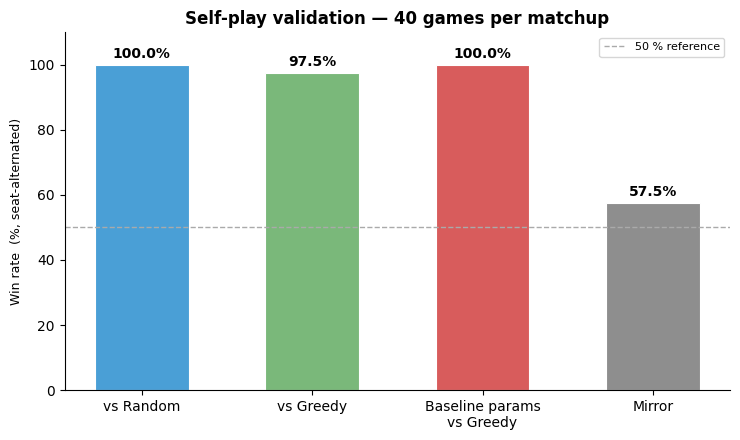

Crustle-policy gain vs greedy:  100.0% → 97.5%  (+-2.5 pp)

submission.tar.gz ready.


In [6]:
try:
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches

    fig, ax = plt.subplots(figsize=(7.5, 4.5))

    labels = ["vs Random", "vs Greedy", "Mirror"]
    values = [
        results.get("random", 0),
        results.get("greedy", 0),
        results.get("mirror", 0),
    ]
    colors = ["#4a9fd6", "#7ab87a", "#8e8e8e"]

    if "base_vs_greedy" in results:
        labels.insert(2, "Baseline params\nvs Greedy")
        values.insert(2, results["base_vs_greedy"])
        colors.insert(2, "#d85c5c")

    bars = ax.bar(labels, values, color=colors, edgecolor="white", linewidth=0.8, width=0.55)
    for bar, v in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2, v + 1.2,
            f"{v:.1f}%", ha="center", va="bottom",
            fontsize=10, fontweight="bold"
        )
    ax.axhline(50, color="#aaa", ls="--", lw=1, label="50 % reference")
    ax.set_ylabel("Win rate  (%, seat-alternated)", fontsize=9)
    ax.set_ylim(0, 110)
    ax.set_title("Self-play validation — 40 games per matchup", fontweight="bold")
    for sp in ("top", "right"):
        ax.spines[sp].set_visible(False)
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

    if "base_vs_greedy" in results:
        delta = results["greedy"] - results["base_vs_greedy"]
        print(f"Crustle-policy gain vs greedy:  "
              f"{results['base_vs_greedy']:.1f}% → {results['greedy']:.1f}%  "
              f"(+{delta:.1f} pp)")
except Exception as ex:
    print(f"Chart skipped: {ex}")
    for k, v in results.items():
        print(f"  {k}: {v:.1f}%")

print("\nsubmission.tar.gz ready.")